# FX Carry Strategy: Final Recommendation

**Recommendation:** keep the validated FX carry book, but protect it by scaling the EM sleeve down when EM risk gets unusually high relative to G10. Treasury futures were the best external overlay class we tested, and 5-year Treasuries helped when paired with de-risking, but the core finding from `em_deleveraging.ipynb` is simpler: **the most direct protection is to reduce the book's own EM crash exposure instead of paying for a standing hedge.**

In plain English, this notebook asks one question: when the carry trade starts becoming a crowded EM risk trade, should we buy insurance from another futures market, or should we just own less of the risky EM sleeve? The evidence points to the second answer.

## 0. Setup

This notebook uses the same shared strategy engine as the rest of the project. The small `load_wide_robust` patch below only handles an environment issue: the local `pyarrow` build can fail on the repo parquet files, while `polars` reads them correctly. The patch keeps the same columns and conventions, then hands the data back to the normal strategy code.

In [1]:
from pathlib import Path
from functools import lru_cache
import ast
import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import openpyxl

warnings.filterwarnings("ignore", category=FutureWarning)


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "strategy").exists() and (p / "arjun").exists():
            return p.resolve()
    return Path("/Users/arjunpatel/GitRepositories/FX_Carry_26_Summer_PL")


REPO = find_repo_root()
ARJUN = REPO / "arjun"
OUT = ARJUN / "outputs"
OUT.mkdir(exist_ok=True)

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from strategy import run, fx_utils as fx

_ORIGINAL_LOAD_WIDE = fx.load_wide


@lru_cache(maxsize=16)
def _polars_raw_group(group):
    import polars as pl

    raw = pl.read_parquet(fx.RAW_DIR / f"{group}_wide.parquet").to_pandas()
    date = pd.to_datetime(raw.pop("date"))
    raw.index = date
    raw.columns = pd.MultiIndex.from_tuples(
        [ast.literal_eval(c) if isinstance(c, str) and c.startswith("(") else c for c in raw.columns],
        names=["ticker", "field"],
    )
    return raw


def load_wide_robust(group: str, field: str = "PX_LAST") -> pd.DataFrame:
    try:
        return _ORIGINAL_LOAD_WIDE(group, field)
    except OSError as err:
        if "Repetition level histogram size mismatch" not in str(err):
            raise

    raw = _polars_raw_group(group)
    df = raw.xs(field, level="field", axis=1)
    df = df.apply(pd.to_numeric, errors="coerce").sort_index()
    df.columns = [
        c.rsplit(" ", 1)[0] if isinstance(c, str) and c.endswith((" Curncy", " Index", " Comdty")) else c
        for c in df.columns
    ]
    return df


fx.load_wide = load_wide_robust

ANN = fx.ANN_DAYS
G10 = ["AUD", "CAD", "CHF", "EUR", "GBP", "JPY", "NOK", "NZD", "SEK"]

plt.rcParams.update({
    "figure.figsize": (10.5, 4.0),
    "axes.grid": True,
    "grid.alpha": 0.28,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)


def sharpe(r):
    r = pd.Series(r).dropna()
    return r.mean() * ANN / (r.std() * np.sqrt(ANN))


def ann_return(r):
    return pd.Series(r).dropna().mean() * ANN


def ann_vol(r):
    return pd.Series(r).dropna().std() * np.sqrt(ANN)


def maxdd_sum(r):
    cum = pd.Series(r).dropna().cumsum()
    return (cum - cum.cummax()).min()

print(f"repo: {REPO}")
print(f"engine annualization: {ANN} trading days")

repo: /Users/arjunpatel/GitRepositories/FX_Carry_26_Summer_PL
engine annualization: 252 trading days


## 1. Why the Final Answer Is Not “Just Add a Hedge”

The carry book already spreads long and short FX exposure across currencies. That makes many obvious hedges weaker than they look. The futures comparison work showed a clean pattern:

- If a futures position really pays during carry crashes, the market charges for it through negative carry.
- If a futures position is cheap to hold, it usually does not move enough against the book.
- Treasuries were the best overlay family, but still did not beat the simple act of stepping out of the carry book during stress.

The chart below keeps that context in view before we focus on the EM deleveraging rule.

,corr_w_book,direction,tail_bp_worst5,carry_pct_yr,best_static_sharpe,read
overlay class,,,,,,
JPY / CHF futures,-0.43,long,+32 to +34,-1.8,0.43,"real tail payoff, but priced as insurance"
Treasury futures,-0.26,long,+11 to +16,0.0,0.53,"best overlay family; cheap, but weaker protection"
S&P 500 futures,0.38,short,+26,-2.7,0.23,wrong-way as a standing position
DXY futures,0.19,short,+5,NaN,0.42,dollar exposure mostly nets out inside the car...
VIX futures,-0.35,long,+27,-33.0,0.31,"convex, but very expensive to hold"


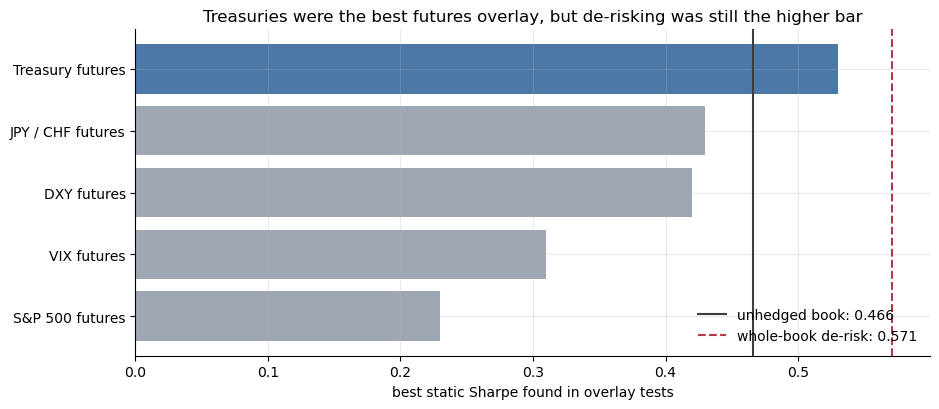

In [2]:
futures_recap = pd.DataFrame(
    [
        ["JPY / CHF futures", -0.43, "long", "+32 to +34", -1.8, 0.43, "real tail payoff, but priced as insurance"],
        ["Treasury futures", -0.26, "long", "+11 to +16", 0.0, 0.53, "best overlay family; cheap, but weaker protection"],
        ["S&P 500 futures", +0.38, "short", "+26", -2.7, 0.23, "wrong-way as a standing position"],
        ["DXY futures", +0.19, "short", "+5", np.nan, 0.42, "dollar exposure mostly nets out inside the carry sort"],
        ["VIX futures", -0.35, "long", "+27", -33.0, 0.31, "convex, but very expensive to hold"],
    ],
    columns=["overlay class", "corr_w_book", "direction", "tail_bp_worst5", "carry_pct_yr", "best_static_sharpe", "read"],
).set_index("overlay class")

display(futures_recap)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
plot_data = futures_recap.sort_values("best_static_sharpe")
colors = ["#4C78A8" if idx == "Treasury futures" else "#A0A7B4" for idx in plot_data.index]
ax.barh(plot_data.index, plot_data["best_static_sharpe"], color=colors)
ax.axvline(0.466, color="#3D3D3D", lw=1.5, label="unhedged book: 0.466")
ax.axvline(0.571, color="#B23A48", lw=1.5, ls="--", label="whole-book de-risk: 0.571")
ax.set_xlabel("best static Sharpe found in overlay tests")
ax.set_title("Treasuries were the best futures overlay, but de-risking was still the higher bar")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

**Interpretation:** Treasuries matter. They were the best external overlay because they have flight-to-quality behavior and do not carry the same running cost as long-vol or funding-currency insurance. But the bigger lesson is that the book is easier to protect by adjusting its own exposure. That is why the final recommendation moves from “what hedge should we bolt on?” to “which part of the carry book should we scale down?”

## 2. Where the Risk Actually Lives

The carry strategy earns most of its premium from EM currencies, and EM is also where the crash risk concentrates. Here I rebuild the validated book using the shared engine, then split its daily P&L into G10 and EM contributions.

The important distinction is:

- `ALL_net` is the actual validated strategy after transaction costs.
- The sleeve split is gross contribution P&L, because it decomposes the book's holdings before costs.

So when we compare the EM deleveraging rule to the sleeve baseline, the fair comparison is gross-to-gross.

In [3]:
base = run()
all_book = base.net.dropna().rename("ALL_net")
all_gross = base.gross.reindex(all_book.index).rename("ALL_gross")
contrib = base.contrib.reindex(all_book.index)

em_names = [c for c in contrib.columns if c not in G10]
g10_names = [c for c in G10 if c in contrib.columns]

g10_sleeve = contrib[g10_names].sum(axis=1).rename("G10_sleeve_in_ALL")
em_sleeve = contrib[em_names].sum(axis=1).rename("EM_sleeve_in_ALL")
book_recon = (g10_sleeve + em_sleeve).rename("gross_reconstructed_book")

recon_gap = (book_recon - all_gross).abs().max()
assert recon_gap < 1e-10, f"sleeves do not reconstruct gross book: {recon_gap}"

sleeve_series = {
    "unhedged book, net": all_book,
    "book reconstructed from sleeves, gross": book_recon,
    "G10 contribution sleeve, gross": g10_sleeve,
    "EM contribution sleeve, gross": em_sleeve,
}
sleeve_stats = pd.DataFrame({
    name: {
        "Sharpe": sharpe(series),
        "ann_return": ann_return(series),
        "ann_vol": ann_vol(series),
        "max_drawdown": maxdd_sum(series),
    }
    for name, series in sleeve_series.items()
}).T

display(sleeve_stats.round(4))
print(f"EM sleeve names ({len(em_names)}): {', '.join(em_names)}")
print(f"sleeve reconstruction gap vs ALL_gross: {recon_gap:.1e}")

,Sharpe,ann_return,ann_vol,max_drawdown
"unhedged book, net",0.4659,0.0521,0.1119,-0.3322
"book reconstructed from sleeves, gross",0.6284,0.0703,0.1118,-0.2977
"G10 contribution sleeve, gross",0.3559,0.0251,0.0704,-0.2788
"EM contribution sleeve, gross",0.4461,0.0452,0.1014,-0.3988


EM sleeve names (18): BRL, CLP, CNH, COP, HUF, IDR, ILS, INR, KRW, MXN, MYR, PEN, PHP, PLN, SGD, THB, TRY, ZAR
sleeve reconstruction gap vs ALL_gross: 6.9e-18


## 3. The Signal: EM Volatility Relative to G10

The rule uses one stress measure: **the recent volatility of the EM sleeve divided by the recent volatility of the G10 sleeve.**

Here is the logic in plain terms:

- The carry book is split into two pieces: the G10 currency contribution and the EM currency contribution.
- Each day, we look back over the last **63 trading days**, roughly three months.
- We compute annualized volatility for the EM sleeve and for the G10 sleeve.
- We divide EM volatility by G10 volatility.

If that ratio is high, EM is not merely volatile in an absolute sense. It is volatile **relative to the safer G10 sleeve**, which is exactly the environment where EM carry drawdowns tend to show up. That ratio is the warning light.

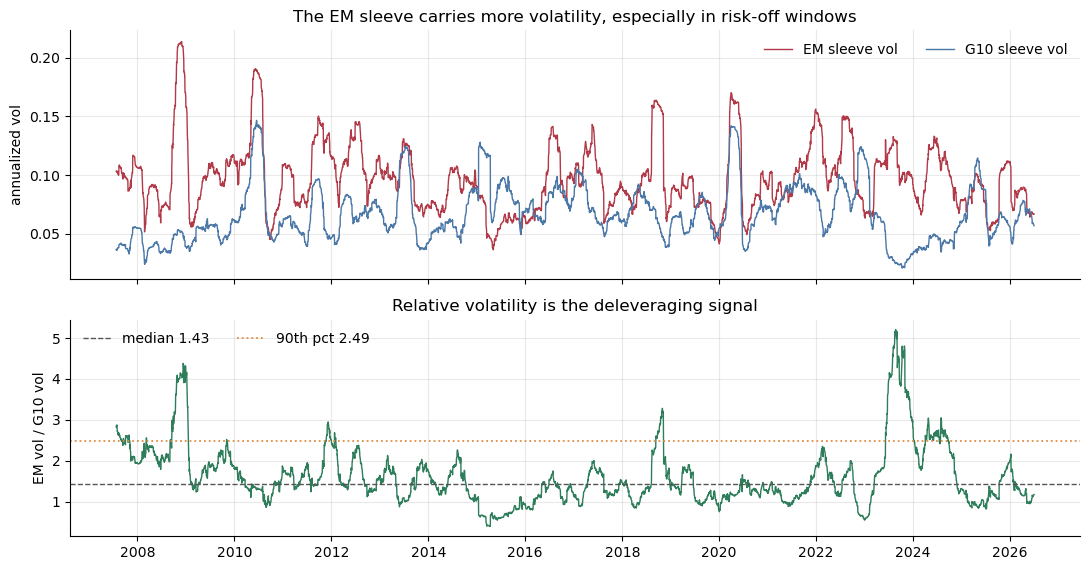

EM/G10 vol ratio: median 1.43, 90th percentile 2.49, max 5.21


In [4]:
WIN = 63
vol_em = em_sleeve.rolling(WIN).std() * np.sqrt(ANN)
vol_g10 = g10_sleeve.rolling(WIN).std() * np.sqrt(ANN)
rel_vol = (vol_em / vol_g10).replace([np.inf, -np.inf], np.nan).rename("EM_over_G10_vol")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 5.8), sharex=True, gridspec_kw={"height_ratios": [1.15, 1]})
ax1.plot(vol_em.index, vol_em, color="#B23A48", lw=1.0, label="EM sleeve vol")
ax1.plot(vol_g10.index, vol_g10, color="#4C78A8", lw=1.0, label="G10 sleeve vol")
ax1.set_ylabel("annualized vol")
ax1.set_title("The EM sleeve carries more volatility, especially in risk-off windows")
ax1.legend(frameon=False, ncol=2)

ax2.plot(rel_vol.index, rel_vol, color="#2E7D5B", lw=1.0)
ax2.axhline(rel_vol.median(), color="#555555", ls="--", lw=1, label=f"median {rel_vol.median():.2f}")
ax2.axhline(rel_vol.quantile(0.90), color="#E08E45", ls=":", lw=1.3, label=f"90th pct {rel_vol.quantile(0.90):.2f}")
ax2.set_ylabel("EM vol / G10 vol")
ax2.set_title("Relative volatility is the deleveraging signal")
ax2.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

print(f"EM/G10 vol ratio: median {rel_vol.median():.2f}, 90th percentile {rel_vol.quantile(0.90):.2f}, max {rel_vol.max():.2f}")

## 4. The Deleveraging Rule

This is the rule as a trading instruction.

**What gets deleveraged?** Only the EM currency sleeve inside the combined carry book. The G10 sleeve is left unchanged. In this book, that means the EM contribution from BRL, CLP, CNH, COP, HUF, IDR, ILS, INR, KRW, MXN, MYR, PEN, PHP, PLN, SGD, THB, TRY, and ZAR.

**How do we know when to deleverage?** We use the EM/G10 volatility ratio from the prior day. Then we compare that ratio with its own expanding history by turning it into a z-score. A z-score near zero means the ratio is normal for this sample. A high positive z-score means EM volatility is unusually high compared with G10.

**How much do we deleverage?** The EM sleeve is scaled by an **EM exposure multiplier** between 100% and 25%:

| Prior-day EM/G10 relative-vol z-score | EM exposure held | EM exposure cut |
|---:|---:|---:|
| `<= 0.50` | `100%` | `0%` |
| `0.75` | `81.25%` | `18.75%` |
| `1.00` | `62.50%` | `37.50%` |
| `1.25` | `43.75%` | `56.25%` |
| `>= 1.50` | `25%` | `75%` |

Between `0.50` and `1.50`, the cut is linear. Below `0.50`, EM stays fully invested. Above `1.50`, EM is held at the 25% floor. The rule is lagged one day, so today's position uses information available through yesterday.

,relative_vol_zscore,EM exposure held,EM exposure cut
0,<= 0.50,100.00%,0.00%
1,0.75,81.25%,18.75%
2,1.00,62.50%,37.50%
3,1.25,43.75%,56.25%
4,>= 1.50,25.00%,75.00%


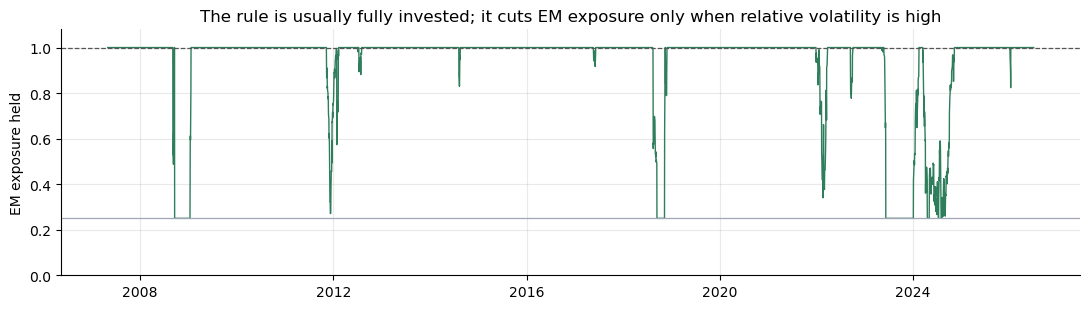

Average EM exposure held: 92.83%
Days at full EM exposure: 86%
Days at the 25% EM floor: 6%
Days with a partial EM cut: 8%


In [5]:
Z_LO, Z_HI, EM_FLOOR = 0.5, 1.5, 0.25

rel_vol_lagged = rel_vol.shift(1)
rel_vol_zscore = (
    (rel_vol_lagged - rel_vol_lagged.expanding(252).mean())
    / rel_vol_lagged.expanding(252).std()
).reindex(all_book.index)


def em_multiplier_from_z(z, z_lo=Z_LO, z_hi=Z_HI, em_floor=EM_FLOOR):
    stress_fraction = ((z - z_lo) / (z_hi - z_lo)).clip(0.0, 1.0)
    return (1.0 - (1.0 - em_floor) * stress_fraction).fillna(1.0)


em_multiplier = em_multiplier_from_z(rel_vol_zscore).rename("EM_exposure_multiplier")

threshold_examples = pd.DataFrame({
    "relative_vol_zscore": ["<= 0.50", "0.75", "1.00", "1.25", ">= 1.50"],
    "EM exposure held": [1.00, 0.8125, 0.6250, 0.4375, 0.25],
})
threshold_examples["EM exposure cut"] = 1.0 - threshold_examples["EM exposure held"]
display(threshold_examples.style.format({"EM exposure held": "{:.2%}", "EM exposure cut": "{:.2%}"}))

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(em_multiplier.index, em_multiplier, color="#2E7D5B", lw=1.0)
ax.axhline(1.0, color="#555555", ls="--", lw=0.9)
ax.axhline(EM_FLOOR, color="#A0A7B4", lw=0.9)
ax.set_ylim(0, 1.08)
ax.set_ylabel("EM exposure held")
ax.set_title("The rule is usually fully invested; it cuts EM exposure only when relative volatility is high")
plt.tight_layout()
plt.show()

print(f"Average EM exposure held: {em_multiplier.mean():.2%}")
print(f"Days at full EM exposure: {(em_multiplier >= 0.999).mean():.0%}")
print(f"Days at the 25% EM floor: {(em_multiplier <= EM_FLOOR + 1e-6).mean():.0%}")
print(f"Days with a partial EM cut: {((em_multiplier < 0.999) & (em_multiplier > EM_FLOOR + 1e-6)).mean():.0%}")

## 5. The Main Result

This table recreates the core comparison from `em_deleveraging.ipynb`. The key row is **relative-vol EM deleverage**. It means: keep the G10 sleeve unchanged, and multiply the EM sleeve by the EM exposure multiplier defined above.

It is compared to the gross reconstructed book because both are sleeve-level gross series. A second control, **whole-book de-risk**, uses an FX-volatility stress trigger and turns the entire net carry book off during stress. That is the bar the futures overlays failed to clear.

In [6]:
def load_jpmvxyg7_from_workbook():
    label_re = re.compile(r"^(.*?)\s+\[(.*?)\]\s+(.*)$")
    candidates = [ARJUN / "updated_bloomberg_data.xlsx", ARJUN / "bloomberg_data_updated.xlsx", ARJUN / "FX_Carry_Bloomberg_DATA_clean.xlsx"]
    wb_path = next((p for p in candidates if p.exists()), None)
    if wb_path is None:
        raise FileNotFoundError("Could not find the Bloomberg workbook in arjun/.")

    wb = openpyxl.load_workbook(wb_path, read_only=True, data_only=True)
    if "FXVol_Indices" not in wb.sheetnames:
        wb.close()
        raise KeyError(f"FXVol_Indices sheet not found in {wb_path.name}")

    grid = [list(r) for r in wb["FXVol_Indices"].iter_rows(values_only=True)]
    wb.close()

    for ri, row in enumerate(grid):
        for ci, cell in enumerate(row):
            if not isinstance(cell, str):
                continue
            m = label_re.match(cell.strip())
            if not m or "JPMVXYG7" not in m.group(2).upper():
                continue
            dates, vals = [], []
            for rr in range(ri + 1, len(grid)):
                r2 = grid[rr]
                d = r2[ci] if ci < len(r2) else None
                if d is None or not hasattr(d, "year"):
                    continue
                v = r2[ci + 1] if ci + 1 < len(r2) else None
                dates.append(pd.Timestamp(d))
                vals.append(v if isinstance(v, (int, float)) else np.nan)
            s = pd.Series(vals, index=pd.DatetimeIndex(dates), dtype="float64").sort_index().dropna()
            return s, wb_path.name
    raise KeyError("JPMVXYG7 was not found in the workbook FXVol_Indices sheet.")


vol_level, vol_source = load_jpmvxyg7_from_workbook()
vol_level = vol_level[vol_level.index.isin(all_book.index)]
vol_z = (vol_level - vol_level.rolling(252, min_periods=252).mean()) / vol_level.rolling(252, min_periods=252).std()
trig_fxvol = (vol_z >= 0.8416).shift(1).reindex(all_book.index).fillna(False).infer_objects(copy=False).astype(bool)

book_relvol = (g10_sleeve + em_multiplier * em_sleeve).rename("relative-vol EM deleverage, gross")
book_emoff = (g10_sleeve + (~trig_fxvol) * em_sleeve).rename("naive EM-off in FX-vol stress, gross")
book_derisk = (all_book * (~trig_fxvol)).rename("whole-book de-risk control, net")

variants = {
    "unhedged book, net": all_book,
    "reconstructed book, gross": book_recon,
    "relative-vol EM deleverage, gross": book_relvol,
    "naive EM-off in FX-vol stress, gross": book_emoff,
    "whole-book de-risk control, net": book_derisk,
}

worst5 = all_book <= all_book.quantile(0.05)
rows = {}
for name, v in variants.items():
    v = v.dropna()
    base_aligned = all_book.reindex(v.index)
    deviation = (v - base_aligned).dropna()
    nw_t = np.nan
    if deviation.abs().sum() > 0:
        nw = sm.OLS(deviation.values, np.ones(len(deviation))).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
        nw_t = float(nw.tvalues[0])
    rows[name] = {
        "Sharpe": sharpe(v),
        "ann_return": ann_return(v),
        "ann_vol": ann_vol(v),
        "max_drawdown": maxdd_sum(v),
        "worst_day": v.min(),
        "vol_reduction_vs_net_%": 100 * (1 - v.std() / all_book.reindex(v.index).std()),
        "tail_bp_on_book_worst5": deviation.reindex(all_book.index[worst5]).mean() * 1e4,
        "deviation_return_%yr": deviation.mean() * ANN * 100,
        "NW_t_vs_net_book": nw_t,
    }

compare = pd.DataFrame(rows).T
compare.to_csv(OUT / "strategy_key_results.csv")

display(compare.round(4))
print(f"FX-vol stress trigger source: {vol_source}")
print(f"FX-vol stress trigger on {trig_fxvol.mean():.1%} of days ({int(trig_fxvol.sum())} days)")
print(f"saved: {OUT / 'strategy_key_results.csv'}")

,Sharpe,ann_return,ann_vol,max_drawdown,worst_day,vol_reduction_vs_net_%,tail_bp_on_book_worst5,deviation_return_%yr,NW_t_vs_net_book
"unhedged book, net",0.4659,0.0521,0.1119,-0.3322,-0.0491,0.0000,0.0000,0.0000,NaN
"reconstructed book, gross",0.6284,0.0703,0.1118,-0.2977,-0.0491,0.0591,1.1786,1.8147,14.2584
"relative-vol EM deleverage, gross",0.6768,0.0717,0.1059,-0.2977,-0.0491,5.3408,15.1630,1.9552,3.4254
"naive EM-off in FX-vol stress, gross",0.7673,0.0771,0.1005,-0.2507,-0.0461,10.1952,45.2692,2.4975,1.8889
"whole-book de-risk control, net",0.5715,0.0529,0.0926,-0.2637,-0.0418,17.2160,60.4812,0.0800,0.0567


FX-vol stress trigger source: updated_bloomberg_data.xlsx
FX-vol stress trigger on 20.9% of days (1043 days)
saved: /Users/arjunpatel/GitRepositories/FX_Carry_26_Summer_PL/arjun/outputs/strategy_key_results.csv


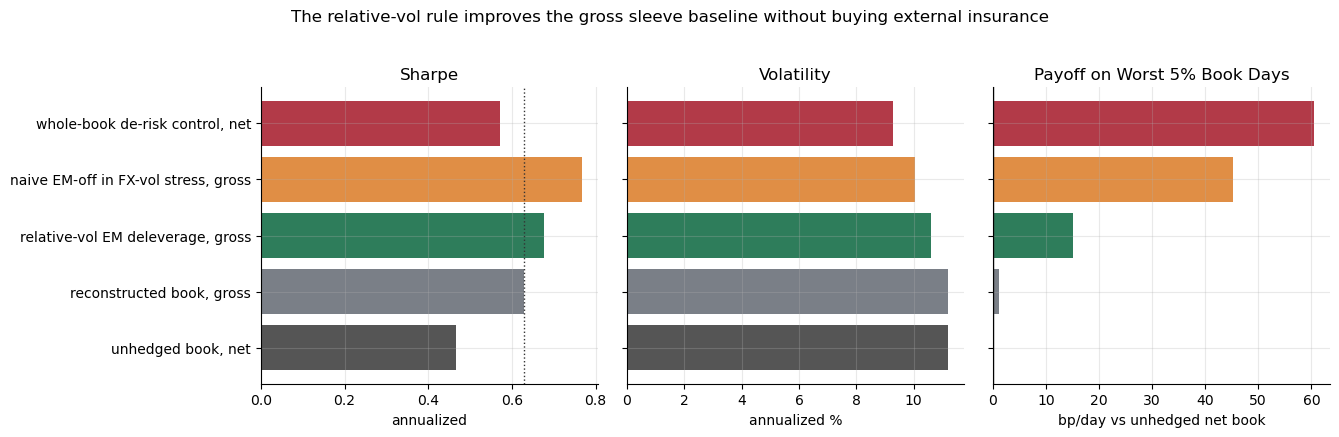

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
order = list(variants.keys())
colors = ["#555555", "#7A7F87", "#2E7D5B", "#E08E45", "#B23A48"]

axes[0].barh(order, compare.loc[order, "Sharpe"], color=colors)
axes[0].axvline(compare.loc["reconstructed book, gross", "Sharpe"], color="#333333", ls=":", lw=1)
axes[0].set_title("Sharpe")
axes[0].set_xlabel("annualized")

axes[1].barh(order, compare.loc[order, "ann_vol"] * 100, color=colors)
axes[1].set_title("Volatility")
axes[1].set_xlabel("annualized %")
axes[1].set_yticklabels([])

axes[2].barh(order, compare.loc[order, "tail_bp_on_book_worst5"], color=colors)
axes[2].axvline(0, color="#333333", lw=1)
axes[2].set_title("Payoff on Worst 5% Book Days")
axes[2].set_xlabel("bp/day vs unhedged net book")
axes[2].set_yticklabels([])

fig.suptitle("The relative-vol rule improves the gross sleeve baseline without buying external insurance", y=1.03, fontsize=12)
plt.tight_layout()
plt.show()

**How to read the table:**

The like-for-like baseline for the EM rule is the gross reconstructed book at **0.628 Sharpe**. The relative-volatility rule lifts that to **0.677**, reduces volatility by about **5.3%**, and adds about **15 bp/day** during the unhedged book's worst 5% of days.

The all-or-nothing EM-off rule has the highest gross Sharpe, but it is intentionally blunt: it depends on a separate FX-vol stress trigger and cuts EM to zero. I treat it as an upper-bound control, not the clean final recommendation. The relative-vol rule is smoother because it says exactly how much EM to hold: normally 100%, gradually less as EM volatility gets abnormal, and never below 25%.

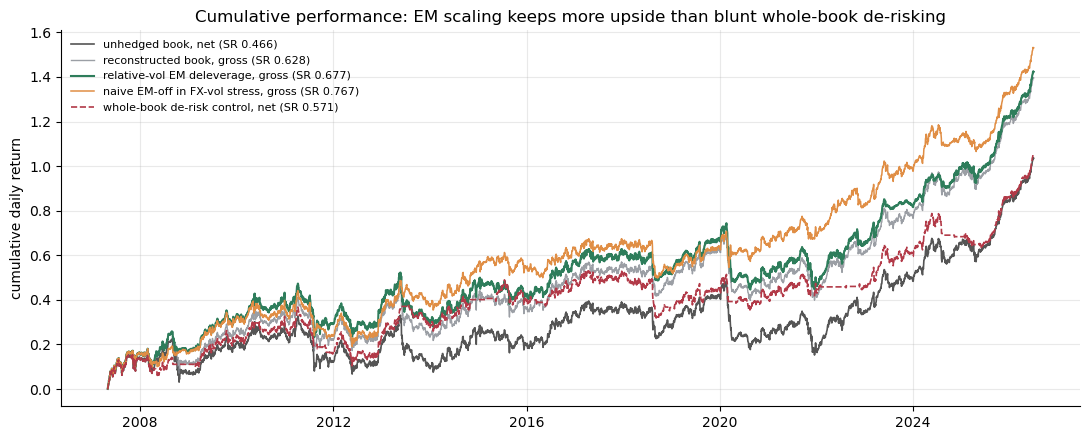

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
style = {
    "unhedged book, net": dict(color="#555555", lw=1.2),
    "reconstructed book, gross": dict(color="#7A7F87", lw=1.0, alpha=0.75),
    "relative-vol EM deleverage, gross": dict(color="#2E7D5B", lw=1.5),
    "naive EM-off in FX-vol stress, gross": dict(color="#E08E45", lw=1.1),
    "whole-book de-risk control, net": dict(color="#B23A48", lw=1.2, ls="--"),
}
for name, series in variants.items():
    v = series.dropna()
    ax.plot(v.index, v.cumsum(), label=f"{name} (SR {sharpe(v):.3f})", **style[name])
ax.set_ylabel("cumulative daily return")
ax.set_title("Cumulative performance: EM scaling keeps more upside than blunt whole-book de-risking")
ax.legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## 6. Robustness Checks

A useful trading rule should not live on one exact parameter value or one lucky subperiod. The checks below repeat the same tests from `em_deleveraging.ipynb`:

- split the sample into four calendar windows;
- sweep the minimum EM exposure floor and the high-z trigger threshold;
- add extra execution lag.

,unhedged,relative-vol rule,whole-book de-risk
2007-2010,0.565,0.977,0.790
2011-2015,-0.082,0.059,0.255
2016-2020,0.075,0.170,0.030
2021-2026,1.281,1.632,1.246


,z_hi 1.00,z_hi 1.25,z_hi 1.50,z_hi 1.75,z_hi 2.00
floor 0.00,0.684,0.687,0.685,0.682,0.681
floor 0.10,0.682,0.684,0.682,0.679,0.678
floor 0.25,0.677,0.679,0.677,0.674,0.672
floor 0.40,0.671,0.672,0.670,0.667,0.666
floor 0.50,0.666,0.666,0.664,0.662,0.660


,relative_vol_rule_sharpe
extra_lag_days,
0,0.677
1,0.680
2,0.696


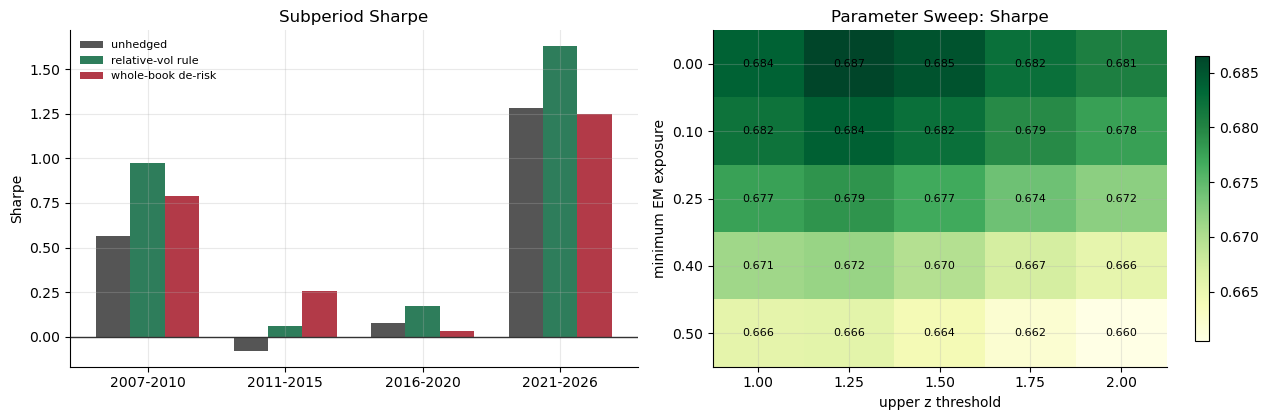

In [9]:
edges = [
    all_book.index[0],
    pd.Timestamp("2011-01-01"),
    pd.Timestamp("2016-01-01"),
    pd.Timestamp("2021-01-01"),
    all_book.index[-1] + pd.Timedelta(days=1),
]
labels = ["2007-2010", "2011-2015", "2016-2020", "2021-2026"]
sub_rows = {}
for label, lo, hi in zip(labels, edges[:-1], edges[1:]):
    mask = (all_book.index >= lo) & (all_book.index < hi)
    sub_rows[label] = {
        "unhedged": sharpe(all_book[mask]),
        "relative-vol rule": sharpe(book_relvol.reindex(all_book.index)[mask]),
        "whole-book de-risk": sharpe(book_derisk.reindex(all_book.index)[mask]),
    }
subperiod = pd.DataFrame(sub_rows).T

def parameter_grid():
    floors = [0.00, 0.10, 0.25, 0.40, 0.50]
    z_his = [1.00, 1.25, 1.50, 1.75, 2.00]
    grid = pd.DataFrame(index=[f"floor {f:.2f}" for f in floors], columns=[f"z_hi {z:.2f}" for z in z_his], dtype=float)
    for f in floors:
        for zh in z_his:
            scenario_em_multiplier = em_multiplier_from_z(rel_vol_zscore, z_hi=zh, em_floor=f)
            grid.loc[f"floor {f:.2f}", f"z_hi {zh:.2f}"] = sharpe(g10_sleeve + scenario_em_multiplier * em_sleeve)
    return grid.astype(float)

grid = parameter_grid()

lag_rows = []
for extra_lag in [0, 1, 2]:
    scenario_em_multiplier = em_multiplier_from_z(rel_vol_zscore.shift(extra_lag)).fillna(1.0)
    lag_rows.append({"extra_lag_days": extra_lag, "relative_vol_rule_sharpe": sharpe(g10_sleeve + scenario_em_multiplier * em_sleeve)})
lag_table = pd.DataFrame(lag_rows).set_index("extra_lag_days")

display(subperiod.round(3))
display(grid.round(3))
display(lag_table.round(3))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.0, 4.3))
x = np.arange(len(subperiod))
w = 0.25
ax1.bar(x - w, subperiod["unhedged"], width=w, color="#555555", label="unhedged")
ax1.bar(x, subperiod["relative-vol rule"], width=w, color="#2E7D5B", label="relative-vol rule")
ax1.bar(x + w, subperiod["whole-book de-risk"], width=w, color="#B23A48", label="whole-book de-risk")
ax1.axhline(0, color="#333333", lw=1)
ax1.set_xticks(x, subperiod.index)
ax1.set_ylabel("Sharpe")
ax1.set_title("Subperiod Sharpe")
ax1.legend(frameon=False, fontsize=8)

im = ax2.imshow(grid.values, cmap="YlGn", aspect="auto")
ax2.set_xticks(range(grid.shape[1]), [c.replace("z_hi ", "") for c in grid.columns])
ax2.set_yticks(range(grid.shape[0]), [i.replace("floor ", "") for i in grid.index])
ax2.set_xlabel("upper z threshold")
ax2.set_ylabel("minimum EM exposure")
ax2.set_title("Parameter Sweep: Sharpe")
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        ax2.text(j, i, f"{grid.iloc[i, j]:.3f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax2, shrink=0.85)
plt.tight_layout()
plt.show()

The rule passes the basic overfit tests. It improves on the unhedged book in each broad subperiod, and the parameter sweep looks like a plateau rather than one isolated lucky dot. Extra lag does not kill the effect, which is important because any strategy that only works with perfect same-day timing is not a strategy.

The practical version of the rule is therefore: **watch the lagged EM/G10 relative-volatility z-score, leave G10 alone, and cut only the EM sleeve from 100% exposure toward 25% exposure as that z-score moves from 0.50 to 1.50.**

## 7. Treasuries in Context

This is where the “Treasuries were best” intuition fits. Among futures overlays, Treasuries were the cleanest external hedge. In the specific de-risk-plus-Treasury check at the end of `em_deleveraging.ipynb`, the 5-year Treasury future (`FV1`) performed best.

But this is a secondary result, not the main recommendation. Treasury futures help because they are positively expected-return, flight-to-quality assets. The EM deleveraging result is more central because it attacks the carry book's own crash channel.

,h_star,de-risk only Sharpe on same dates,de-risk + Treasury Sharpe,Treasury standalone Sharpe
Treasury future,,,,
TU1 2Y,1.2356,0.5050,0.5250,0.0383
FV1 5Y,0.5188,0.5826,0.6061,0.0388
TY1 10Y,0.3225,0.5472,0.5691,0.0439
US1 long bond,0.1533,0.5153,0.5358,0.0630


saved: /Users/arjunpatel/GitRepositories/FX_Carry_26_Summer_PL/arjun/outputs/strategy_treasury_overlay_check.csv


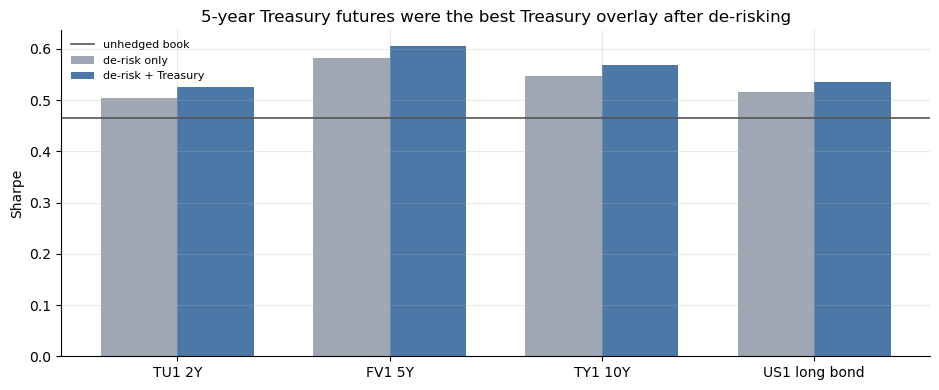

In [10]:
def load_workbook_ticker(sheet, ticker, field="PX_LAST"):
    label_re = re.compile(r"^(.*?)\s+\[(.*?)\]\s+(.*)$")
    candidates = [ARJUN / "updated_bloomberg_data.xlsx", ARJUN / "bloomberg_data_updated.xlsx", ARJUN / "FX_Carry_Bloomberg_DATA_clean.xlsx"]
    wb_path = next((p for p in candidates if p.exists()), None)
    if wb_path is None:
        raise FileNotFoundError("Could not find the Bloomberg workbook in arjun/.")

    wb = openpyxl.load_workbook(wb_path, read_only=True, data_only=True)
    grid = [list(r) for r in wb[sheet].iter_rows(values_only=True)]
    wb.close()

    for ri, row in enumerate(grid):
        for ci, cell in enumerate(row):
            if not isinstance(cell, str):
                continue
            m = label_re.match(cell.strip())
            if not m or m.group(2).strip().upper() != ticker.upper():
                continue
            fields = [f.strip() for f in m.group(3).split(",")]
            if field not in fields:
                continue
            k_field = fields.index(field)
            dates, vals = [], []
            for rr in range(ri + 1, len(grid)):
                r2 = grid[rr]
                d = r2[ci] if ci < len(r2) else None
                if d is None or not hasattr(d, "year"):
                    continue
                v = r2[ci + 1 + k_field] if ci + 1 + k_field < len(r2) else None
                dates.append(pd.Timestamp(d))
                vals.append(v if isinstance(v, (int, float)) else np.nan)
            return pd.Series(vals, index=pd.DatetimeIndex(dates), dtype="float64").sort_index()
    raise KeyError(f"{ticker} {field} not found in sheet {sheet}")


def clean_futures_return(level, name):
    level = level.dropna()
    level = level[level.index.isin(all_book.index)]
    r = level.pct_change()
    r = r[r != 0.0].dropna()
    return r.rename(name)


treasury_returns = {
    "TU1 2Y": clean_futures_return(load_workbook_ticker("Duration", "TU1 Comdty"), "TU1"),
    "FV1 5Y": clean_futures_return(load_workbook_ticker("Duration", "FV1 Comdty"), "FV1"),
    "TY1 10Y": clean_futures_return(load_workbook_ticker("Duration", "TY1 Comdty"), "TY1"),
    "US1 long bond": clean_futures_return(load_workbook_ticker("Duration", "US1 Comdty"), "US1"),
}

rows = []
for name, fut_ret in treasury_returns.items():
    idx = all_book.index.intersection(fut_ret.index)
    b = all_book.loc[idx]
    x = fut_ret.loc[idx]
    trig = trig_fxvol.reindex(idx).fillna(False).astype(bool)
    derisked = b * (~trig)
    h_star = -derisked.cov(x) / x.var()
    combined = derisked + h_star * x
    rows.append({
        "Treasury future": name,
        "h_star": h_star,
        "de-risk only Sharpe on same dates": sharpe(derisked),
        "de-risk + Treasury Sharpe": sharpe(combined),
        "Treasury standalone Sharpe": sharpe(x),
    })

treasury_table = pd.DataFrame(rows).set_index("Treasury future")
treasury_table.to_csv(OUT / "strategy_treasury_overlay_check.csv")
display(treasury_table.round(4))
print(f"saved: {OUT / 'strategy_treasury_overlay_check.csv'}")

fig, ax = plt.subplots(figsize=(9.5, 4.0))
x = np.arange(len(treasury_table))
width = 0.36
ax.bar(x - width/2, treasury_table["de-risk only Sharpe on same dates"], width=width, color="#A0A7B4", label="de-risk only")
ax.bar(x + width/2, treasury_table["de-risk + Treasury Sharpe"], width=width, color="#4C78A8", label="de-risk + Treasury")
ax.axhline(sharpe(all_book), color="#555555", lw=1.2, label="unhedged book")
ax.set_xticks(x, treasury_table.index)
ax.set_ylabel("Sharpe")
ax.set_title("5-year Treasury futures were the best Treasury overlay after de-risking")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## 8. Final Recommendation

The final strategy recommendation is:

1. **Keep the validated carry book as the base.** The project should not replace the core signal just because the unhedged book is crash-prone.
2. **Risk-manage the EM sleeve directly.** Each day, measure the 63-day volatility of the EM sleeve relative to the G10 sleeve. Use yesterday's relative-volatility z-score to decide the EM exposure: 100% if the z-score is `0.50` or lower, linearly cut exposure between `0.50` and `1.50`, and hold only 25% of EM if the z-score is `1.50` or higher. G10 stays unchanged.
3. **Treat Treasuries as the best secondary overlay, not the headline answer.** A de-risk-plus-5Y-Treasury check reaches about **0.606** Sharpe on the tested net setup, which is useful, but it is still a supporting hedge result. The cleaner research finding is that the carry book should first reduce its own EM exposure when EM volatility spikes.
4. **Be explicit about implementation.** The headline EM-scaling result is a gross sleeve-level test. A production notebook should turn the EM exposure multiplier into actual monthly or weekly weight changes and re-run the cost model before quoting tradable live P&L. The economic recommendation survives that caveat: protect the carry book at the source, where the EM crash risk lives.